# Detection ROC curves

A companion search over a grid ends with a number, such as the best $\Delta\chi^2$, a peak signal-to-noise ratio or an evidence ratio. On its own that number does not say how often noise alone would give a value as large, nor how often a real companion of a given flux would be found. This tutorial measures both by simulation for a small aperture-masking observation, using [`detection_statistics`](api/detection.md#virgil.detection.detection_statistics), and combines them into receiver operating characteristic (ROC) curves: the fraction of real companions detected (the true-positive rate) against the fraction of companion-free observations wrongly flagged (the false-positive rate) as the detection threshold varies.

You should come away with three points. The local Wilks significance of a $\Delta\chi^2$, which is right for one position fixed in advance, overstates the significance of the best of many positions on a grid (the look-elsewhere effect), so a threshold for a chosen false-alarm probability has to come from simulated null observations over the same grid. The three statistics that `detection_statistics` returns can be compared on equal terms through their ROC curves. And the completeness at a calibrated threshold is the number to quote after a non-detection, next to the [contrast limits](contrast_limits.md) of the Absil and Ruffio methods.

This page uses only the first stage of the plan in `design/detection_roc.md`: the statistics themselves. The few lines of NumPy that turn simulated statistics into false-alarm rates, ROC curves and thresholds will be replaced by a `DetectionMC` container in the next stage.

## Setup

We simulate the 7-hole NIRISS aperture mask at 4.3 µm with [`nrm_oidata`](api/coverage.md#virgil.coverage.nrm_oidata), which gives 21 squared visibilities with errors of 0.01 and 35 closure phases with errors of 0.5°. Its longest baseline is about 5.3 m, so $\lambda/B \approx 170$ mas. The scene without a companion is a point-source primary, which is a `BinaryModelCartesian` with companion flux zero; that is also the null hypothesis of `detection_statistics`, which sets the companion flux to zero and keeps everything else.

The search grid covers ±180 mas in both coordinates in steps of 20 mas, and 32 fluxes spaced logarithmically from $2\times10^{-4}$ to $3\times10^{-2}$ (fluxes are always companion/primary). The flux axis plays two roles: it is the starting grid of the optimizer that refines the best flux at each position, and it is the prior of the log Bayes factor, which is then uniform in log flux between its ends. The grid is deliberately coarse, so that thousands of simulated searches take a minute or two on a CPU. We also fix the false-alarm probability (FAP) that we will calibrate later: 0.135%, the one-sided Gaussian tail at 3σ, which is the FAP that [`local_nsigma`](api/detection.md#virgil.detection.local_nsigma) calls 3σ. It is one-sided because the companion flux cannot be negative, so only upward fluctuations count; the often quoted 0.27% is the two-sided value.

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp
from scipy import stats
from tqdm.auto import tqdm

from virgil.coverage import nrm_oidata
from virgil.detection import detection_statistics, local_nsigma
from virgil.limits import flux_to_delta_mag
from virgil.models import BinaryModelCartesian
from virgil.plotting import set_style

set_style()  # the figure style used throughout the docs

template = nrm_oidata()  # 21 V² and 35 closure phases, no values yet
grid = {
    "dra": jnp.linspace(-180.0, 180.0, 19),
    "ddec": jnp.linspace(-180.0, 180.0, 19),
    "flux": jnp.geomspace(2e-4, 3e-2, 32),
}
FAP = stats.norm.sf(3.0)  # 0.135%: what local_nsigma calls 3 sigma

print(
    f"{template.vis.size} V² and {template.phi.size} closure phases; grid of "
    f"{grid['dra'].size * grid['ddec'].size} positions × "
    f"{grid['flux'].size} fluxes; FAP = {FAP:.3%}"
)

21 V² and 35 closure phases; grid of 361 positions × 32 fluxes; FAP = 0.135%


## Null simulations

`detection_statistics` reduces a search over the grid to three numbers. $\Delta\chi^2$ is twice the gain in log likelihood of the best companion on the grid, with its flux refined and constrained to be non-negative, over no companion. The log Bayes factor is the log of the likelihood ratio averaged over the grid, a grid-marginalised evidence for "a companion somewhere" against "none"; on a grid this coarse it is a valid test statistic but not an accurate evidence. The maximum SNR is the largest best-fit flux divided by its Laplace uncertainty, the significance map of the composition tutorial.

The function is traceable in the data, so we can map it over simulated observations with `jax.lax.map` inside one `jax.jit` and it compiles once. The function `search` below takes a batch of random keys and a companion flux. Each key draws a companion position, uniform in separation between 50 and 170 mas and in position angle, and a noise realisation from the template's errors, via [`OIData.with_model`](api/oidata.md#virgil.oidata.OIData.with_model). With flux zero the companion contributes nothing, so these are null observations; with a positive flux the same function gives injections, without recompiling. The helper `run` calls it on batches of 300 simulations, one batch per flux in its list, with a progress bar. Here we run 3000 null simulations.

In [2]:
STATS = ("delta_chi2", "log_bayes_factor", "max_snr")
BATCH = 300


@jax.jit
def search(keys, flux):
    def one(key):
        pos_key, noise_key = jax.random.split(key)
        sep = jax.random.uniform(pos_key, minval=50.0, maxval=170.0)
        pa = jax.random.uniform(
            jax.random.fold_in(pos_key, 1), maxval=2 * jnp.pi
        )
        scene = BinaryModelCartesian(
            sep * jnp.sin(pa), sep * jnp.cos(pa), flux
        )
        data = template.with_model(scene, key=noise_key)
        result = detection_statistics(data, BinaryModelCartesian, grid)
        return {name: result[name] for name in STATS}

    return jax.lax.map(one, keys)


def run(fluxes, seed):
    keys = jax.random.split(jax.random.PRNGKey(seed), (len(fluxes), BATCH))
    batches = [
        search(k, f) for k, f in tqdm(list(zip(keys, fluxes)), leave=False)
    ]
    return {s: onp.stack([onp.asarray(b[s]) for b in batches]) for s in STATS}


start = time.perf_counter()
null = {s: v.reshape(-1) for s, v in run([0.0] * 10, seed=0).items()}
print(
    f"{null['delta_chi2'].size} null searches in {time.perf_counter() - start:.0f} s: "
    f"median Δχ² = {onp.median(null['delta_chi2']):.2f}, "
    f"largest = {null['delta_chi2'].max():.1f}"
)

  0%|          | 0/10 [00:00<?, ?it/s]

3000 null searches in 174 s: median Δχ² = 2.17, largest = 25.0


## The look-elsewhere effect

At one position fixed in advance, $\Delta\chi^2$ under the null is zero half the time (when the best flux would be negative) and follows $\chi^2_1$ otherwise, so its tail is $\tfrac{1}{2}\chi^2_1$ (Wilks's theorem with a parameter on its boundary, Chernoff 1954). That is the reference behind `local_nsigma`. A grid search takes the best of hundreds of positions, and although neighbouring positions are correlated, the best of many is much larger than any one. The plot shows the empirical probability that a null search exceeds a threshold, against the local reference: the grid search's tail sits far above it, and the horizontal line at our FAP shows how much higher the threshold must be.

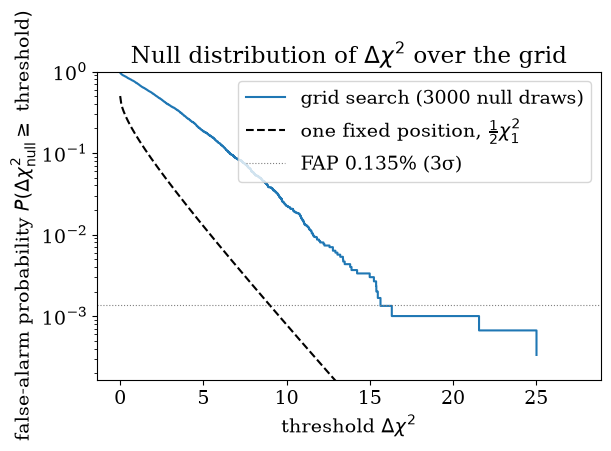

In [3]:
d0 = onp.sort(null["delta_chi2"])
exceed = 1.0 - onp.arange(d0.size) / d0.size  # P(null Δχ² >= each value)
x = onp.linspace(0.0, 1.1 * d0[-1], 400)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.step(d0, exceed, where="post", label=f"grid search ({d0.size} null draws)")
ax.plot(
    x,
    0.5 * stats.chi2(1).sf(x),
    "k--",
    label=r"one fixed position, $\frac{1}{2}\chi^2_1$",
)
ax.axhline(FAP, color="grey", lw=0.8, ls=":", label=f"FAP {FAP:.3%} (3σ)")
ax.set_yscale("log")
ax.set_ylim(0.5 / d0.size, 1.0)
ax.set_xlabel(r"threshold $\Delta\chi^2$")
ax.set_ylabel(
    r"false-alarm probability $P(\Delta\chi^2_{\rm null} \geq$ threshold$)$"
)
ax.set_title(r"Null distribution of $\Delta\chi^2$ over the grid")
ax.legend(loc="upper right");

## Injections

Now we inject companions at six fluxes from $10^{-3}$ to $8\times10^{-3}$, 300 simulations each, at random positions in the same annulus and with fresh noise, and keep the same three statistics. A flux of $10^{-3}$ is roughly the uncertainty of a companion's flux at these separations, so the injections run from barely visible to obvious. The table gives the median of each statistic per flux; all three rise steadily with flux.

In [4]:
FLUXES = [1e-3, 2e-3, 3e-3, 4e-3, 6e-3, 8e-3]
injected = run(FLUXES, seed=1)  # one row of 300 simulations per flux

print(f"{'flux':>8}{'Δmag':>6}{'Δχ²':>8}{'log B':>8}{'max SNR':>9}  (medians)")
for i, flux in enumerate(FLUXES):
    medians = [onp.median(injected[s][i]) for s in STATS]
    print(
        f"{flux:8.0e}{float(flux_to_delta_mag(flux)):6.2f}"
        + "".join(f"{m:{w}.1f}" for m, w in zip(medians, (8, 8, 9)))
    )

  0%|          | 0/6 [00:00<?, ?it/s]

    flux  Δmag     Δχ²   log B  max SNR  (medians)
   1e-03  7.50     4.8    -0.4      2.2
   2e-03  6.75     8.2     0.4      2.8
   3e-03  6.31    15.0     2.5      3.8
   4e-03  5.99    24.0     6.1      4.9
   6e-03  5.55    50.4    18.1      7.0
   8e-03  5.24    91.5    37.9      9.4


## ROC curves

For each statistic, every null value is a possible threshold: its false-positive rate is the fraction of null searches at or above it, and its true-positive rate is the fraction of injections at or above it. The function `roc` below does this in three lines; the `DetectionMC` container of the next stage will do it, with uncertainties. We plot the curves for the faint ($2\times10^{-3}$) and moderate ($4\times10^{-3}$) injections with a logarithmic false-positive axis, because the interesting region is at small false-alarm rates; the dash-dotted vertical line is our FAP, and the thin grey curve is a statistic that cannot tell companions from noise (true-positive rate equal to false-positive rate, which is a curve rather than a straight line on a logarithmic axis). Only the ordering of a statistic's values matters for its ROC curve, so the three can be compared directly. The curves for $\Delta\chi^2$ and the maximum SNR almost coincide: for a faint companion the likelihood is nearly quadratic in flux, so the maximum SNR is close to $\sqrt{\Delta\chi^2}$ and ranks the simulations in the same order. The log Bayes factor averages over positions instead of taking the best one, so it can rank them differently; at the smallest false-positive rates only a handful of null draws set each curve, so differences there are within the noise.

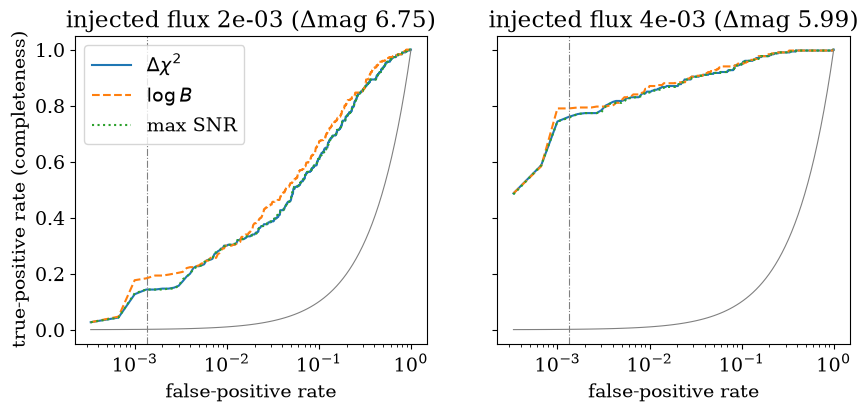

In [5]:
def roc(null_scores, injected_scores):
    thresholds = onp.sort(null_scores)[::-1]
    fpr = onp.arange(1, thresholds.size + 1) / thresholds.size
    return fpr, (injected_scores[:, None] >= thresholds).mean(axis=0)


labels = {
    "delta_chi2": r"$\Delta\chi^2$",
    "log_bayes_factor": r"$\log B$",
    "max_snr": "max SNR",
}
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, i in zip(axes, [FLUXES.index(2e-3), FLUXES.index(4e-3)]):
    for s, ls in zip(STATS, ("-", "--", ":")):
        ax.plot(*roc(null[s], injected[s][i]), ls=ls, label=labels[s])
    chance = onp.geomspace(1 / d0.size, 1.0, 100)
    ax.plot(chance, chance, color="grey", lw=0.8)  # TPR = FPR
    ax.axvline(FAP, color="grey", lw=0.8, ls="-.")
    ax.set_xscale("log")
    ax.set_xlabel("false-positive rate")
    ax.set_title(
        f"injected flux {FLUXES[i]:.0e} (Δmag {float(flux_to_delta_mag(FLUXES[i])):.2f})"
    )
axes[0].set_ylabel("true-positive rate (completeness)")
axes[0].legend();

## Thresholds and completeness

Finally, the calibration. The empirical $\Delta\chi^2$ threshold for our FAP is the corresponding quantile of the null searches, to compare with Wilks's local threshold of 9 (where `local_nsigma` gives 3σ). With 3000 null draws only four lie above a 0.135% quantile, so the empirical threshold is rough; the next stage will attach a bootstrap error to it, and production runs use many more draws. The table then gives the completeness, the fraction of injections detected, at each threshold. Wilks's threshold finds more companions only because its real false-alarm probability over this grid is much higher than 0.135%, as the second line shows.

In [6]:
threshold = onp.quantile(null["delta_chi2"], 1.0 - FAP)
wilks = 9.0  # local_nsigma(9) = 3
print(
    f"Δχ² threshold at FAP {FAP:.3%}: empirical {threshold:.1f} "
    f"(local {float(local_nsigma(threshold)):.1f}σ), Wilks {wilks:.0f} (local 3σ)"
)
print(
    f"Wilks's threshold over this grid has FAP {onp.mean(null['delta_chi2'] >= wilks):.1%}\n"
)
print(
    f"{'flux':>8}{'Δmag':>6}{'complete, empirical':>21}{'complete, Wilks':>17}"
)
for i, flux in enumerate(FLUXES):
    d = injected["delta_chi2"][i]
    print(
        f"{flux:8.0e}{float(flux_to_delta_mag(flux)):6.2f}"
        f"{onp.mean(d >= threshold):21.0%}{onp.mean(d >= wilks):17.0%}"
    )

Δχ² threshold at FAP 0.135%: empirical 15.5 (local 3.9σ), Wilks 9 (local 3σ)
Wilks's threshold over this grid has FAP 3.8%

    flux  Δmag  complete, empirical  complete, Wilks
   1e-03  7.50                   2%              16%
   2e-03  6.75                  14%              42%
   3e-03  6.31                  47%              80%
   4e-03  5.99                  77%              91%
   6e-03  5.55                  94%              99%
   8e-03  5.24                  99%             100%


## Summary

We reduced thousands of simulated companion searches to three statistics each with `detection_statistics`, mapped over random keys with `jax.lax.map` in a single compilation. The null simulations showed the look-elsewhere effect directly: the best $\Delta\chi^2$ on the grid exceeds Wilks's single-position reference by a wide margin, so a threshold for a given false-alarm probability must come from simulated nulls over the same grid and observation, and `local_nsigma` should only ever be reported as a local significance. The ROC curves compare the statistics on equal terms, and the completeness at the calibrated threshold is the honest measure of what a search could have found, to set next to the [contrast limits](contrast_limits.md) of the Absil and Ruffio methods.

This is the first stage of the plan in `design/detection_roc.md`. The next stages add Gaussian and residual-bootstrap null simulators, the Monte Carlo driver and the `DetectionMC` container (false-alarm probabilities with binomial errors, thresholds with bootstrap errors, ROC curves, completeness maps and empirical contrast curves, saved and merged across cluster jobs), and plotting functions for all of these. Nuisance parameters, such as the null scene's own parameters or an error inflation, are held fixed here; refitting them for every draw comes later.